In [14]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

from neural_reconstruction.core.topology import TopologyBuilder
from neural_reconstruction.core.pathfinding import PathFinder
from neural_reconstruction.algorithms.fragment_linking.utils import compute_vector_angle,is_direction_too_similar
from neural_reconstruction.core.preprocessing import dilate_epidermis_vertically

import skimage as ski
# from skimage.measure import label
from scipy.spatial import KDTree


In [15]:
BASE_PATH = Path('/home/pony/projects/ienf_q/data_0331')
IMAGE_ID = 'S222-2_a'



In [16]:
image      = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/image.png',       cv2.IMREAD_COLOR_RGB)[:, :, 1]  # 只取綠色通道
mask       = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/mask.png',        cv2.IMREAD_GRAYSCALE)
annotation = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/weka.png',        cv2.IMREAD_GRAYSCALE)
label      = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/label.png',       cv2.IMREAD_GRAYSCALE)


In [17]:

roi_mask = dilate_epidermis_vertically(mask, offset_px=50)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (51, 51))
background = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
image = cv2.subtract(image, background)

roi_image = cv2.bitwise_and(image, image, mask=roi_mask)
roi_annotation = cv2.bitwise_and(annotation, annotation, mask=roi_mask)

# apply opening to roi_annotation to remove small noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
# roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_OPEN, kernel)

# apply closing to roi_annotation to fill small holes
roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_CLOSE, kernel, iterations=3)
roi_annotation[roi_annotation > 0] = 255


gt_builder = TopologyBuilder()
roi_label = cv2.bitwise_and(label, label, mask=roi_mask)
roi_label = cv2.morphologyEx(roi_label, cv2.MORPH_CLOSE, kernel, iterations=3)
gt_graph = gt_builder.build_seed_graph(roi_label)


/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [18]:

annotation_component = np.asarray(ski.measure.label(roi_annotation, connectivity=2))

# 2. 骨架化 + 種子切分
topology_builder = TopologyBuilder(segment_length=3.0)
global_graph = topology_builder.build_seed_graph(roi_annotation, roi_image)

# 從 labeled image 補上 component_id
for node in global_graph.nodes():
    y, x = node
    global_graph.nodes[node]["component_id"] = int(annotation_component[int(y), int(x)])

# 元件內邊設低成本
# for u, v, data in global_graph.edges(data=True):
#     data["weight"] = 1e-5
# 3. 元件間路徑查找
cost_map = ((255 - roi_image.astype(np.float64)) / 255) ** 2


In [19]:
path_finder = PathFinder(cost_map)
topology_points = np.array(list(global_graph.nodes()))

kdtree = KDTree(topology_points)
seed_map = np.zeros_like(cost_map, dtype=bool)
for p in topology_points:
    seed_map[p[0], p[1]] = True

path_finder = PathFinder(cost_map)
topology_points = np.array(list(global_graph.nodes()))

path_lookup = path_finder.find_paths_from_seeds(
    topology_points=topology_points,
    kdtree=kdtree,
    search_radius=50,
    seed_map=seed_map,
    label_img=annotation_component,
)

In [20]:

# ============================================================
# Featurized Path Pair
# ============================================================
import pandas as pd
from skimage.feature import hessian_matrix

# --- Precompute Hessian-based fiber orientation for the whole image ---
SIGMA = 2
img_float = roi_image.astype(np.float64)
Hrr, Hrc, Hcc = hessian_matrix(img_float, sigma=SIGMA, order='rc')

# For a bright fiber on a dark background:
#   - Across-fiber: large negative eigenvalue λ1
#   - Along-fiber:  near-zero eigenvalue λ2  ← the direction we want
# λ2 = (Hrr + Hcc)/2 + sqrt(((Hrr-Hcc)/2)^2 + Hrc^2)
# Eigenvector of λ2:  v ∝ [Hrc, λ2 - Hrr]  (in (y, x) coordinates)

discriminant = np.sqrt(((Hrr - Hcc) / 2) ** 2 + Hrc ** 2)
lam2 = (Hrr + Hcc) / 2 + discriminant   # larger eigenvalue

fiber_vy = Hrc
fiber_vx = lam2 - Hrr
fiber_norm = np.sqrt(fiber_vy ** 2 + fiber_vx ** 2)
fiber_norm = np.where(fiber_norm < 1e-10, 1.0, fiber_norm)

orient_y = fiber_vy / fiber_norm   # (H, W) unit-vector y-component
orient_x = fiber_vx / fiber_norm   # (H, W) unit-vector x-component

def get_orientation(pt):
    """Return unit fiber-direction vector (dy, dx) at seed point pt=(y,x)."""
    y, x = int(pt[0]), int(pt[1])
    return np.array([orient_y[y, x], orient_x[y, x]])

print(f"Orientation field computed (sigma={SIGMA}). Shape: {orient_y.shape}")


/tmp/ipykernel_1279936/3427218948.py:10: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  Hrr, Hrc, Hcc = hessian_matrix(img_float, sigma=SIGMA, order='rc')


Orientation field computed (sigma=2). Shape: (2051, 7582)


In [21]:
from scipy.interpolate import interp1d

label_component = np.asarray(ski.measure.label(roi_label, connectivity=2))

valid_path = []
invalid_path = []
seen = set()
for (source, target), (path, cost) in path_lookup.items():
    key = (min(source, target), max(source, target))
    if key in seen:
        continue
    seen.add(key)

    path_arr = np.array(path)
    middle = path_arr[1:-1]

    mostly_on_annotation = (
        len(middle) > 0 and
        np.mean(roi_label[middle[:, 0], middle[:, 1]] > 0) >= 0.7
    )
    same_component = (
        label_component[int(source[0]), int(source[1])] ==
        label_component[int(target[0]), int(target[1])]
    )

    if mostly_on_annotation and same_component:
        valid_path.append((source, target, path, cost))
    else:
        invalid_path.append((source, target, path, cost))

print(f"Valid paths:   {len(valid_path)}")
print(f"Invalid paths: {len(invalid_path)}")

Valid paths:   1153
Invalid paths: 2908


In [ ]:

# ============================================================
# Feature extraction
# ============================================================

def extract_path_features(source, target, path, cost):
    """
    Group 1 – Cost features
        mean_cost   : cost / path_length  (average per-step cost)
        cost_std    : std of per-pixel cost_map values along path
        max_cost    : maximum per-pixel cost along path (darkest point)
        path_length : number of pixels in path

    Group 2 – Geometric features (Hessian-based local orientation)
        angle_A  : angle between fiber orientation at A and A→B direction [0,90]°
        angle_B  : angle between fiber orientation at B and B→A direction [0,90]°
        angle_AB : consistency of tangents at A and B – how "parallel" they are [0,90]°
                   0° = smooth curve, 90° = orientations are perpendicular
    """
    path_arr = np.array(path)
    path_length = len(path_arr)

    # --- Group 1: Cost features ---
    step_costs = cost_map[path_arr[:, 0], path_arr[:, 1]]
    mean_cost  = cost / path_length
    cost_std   = float(np.std(step_costs))
    max_cost   = float(np.max(step_costs))

    # --- Group 2: Geometric features ---
    o_A = get_orientation(source)   # local fiber direction at A
    o_B = get_orientation(target)   # local fiber direction at B

    # Connection direction A→B (unit vector)
    conn = np.array(target, dtype=float) - np.array(source, dtype=float)
    conn_unit = conn / (np.linalg.norm(conn) + 1e-10)

    # Tangent-connection angle: use abs(dot) because orientation is undirected
    def _angle_undirected(v, u):
        return float(np.degrees(np.arccos(np.clip(abs(np.dot(v, u)), 0.0, 1.0))))

    angle_A = _angle_undirected(o_A,  conn_unit)   # A's orientation vs A→B
    angle_B = _angle_undirected(o_B, -conn_unit)   # B's orientation vs B→A

    # Tangent consistency: align o_B to o_A's half-space, then measure angle
    o_B_aligned = o_B if np.dot(o_A, o_B) >= 0 else -o_B
    angle_AB =  abs(float(np.degrees(np.arccos(np.clip(np.dot(o_A, o_B_aligned), -1.0, 1.0)))))

    

    return dict(
        mean_cost=mean_cost,
        cost_std=cost_std,
        max_cost=max_cost,
        path_length=path_length,
        angle_A=angle_A,
        angle_B=angle_B,
        angle_AB=angle_AB,
    )

# Build feature dataframe
records = []
for split, path_list in [('valid', valid_path), ('invalid', invalid_path)]:
    for source, target, path, cost in path_list:
        feat = extract_path_features(source, target, path, cost)
        feat['label'] = split
        records.append(feat)

df = pd.DataFrame(records)
print(df.groupby('label')[['mean_cost', 'cost_std', 'max_cost', 'path_length',
                            'angle_A', 'angle_B', 'angle_AB']].mean().T.to_string())


label          invalid      valid
mean_cost     0.929258   0.767783
cost_std      0.094539   0.072921
max_cost      0.911268   0.769231
path_length  29.863136  20.923677
angle_A      48.789776  29.903810
angle_B      50.897130  31.816766
angle_AB     42.066940  37.988603


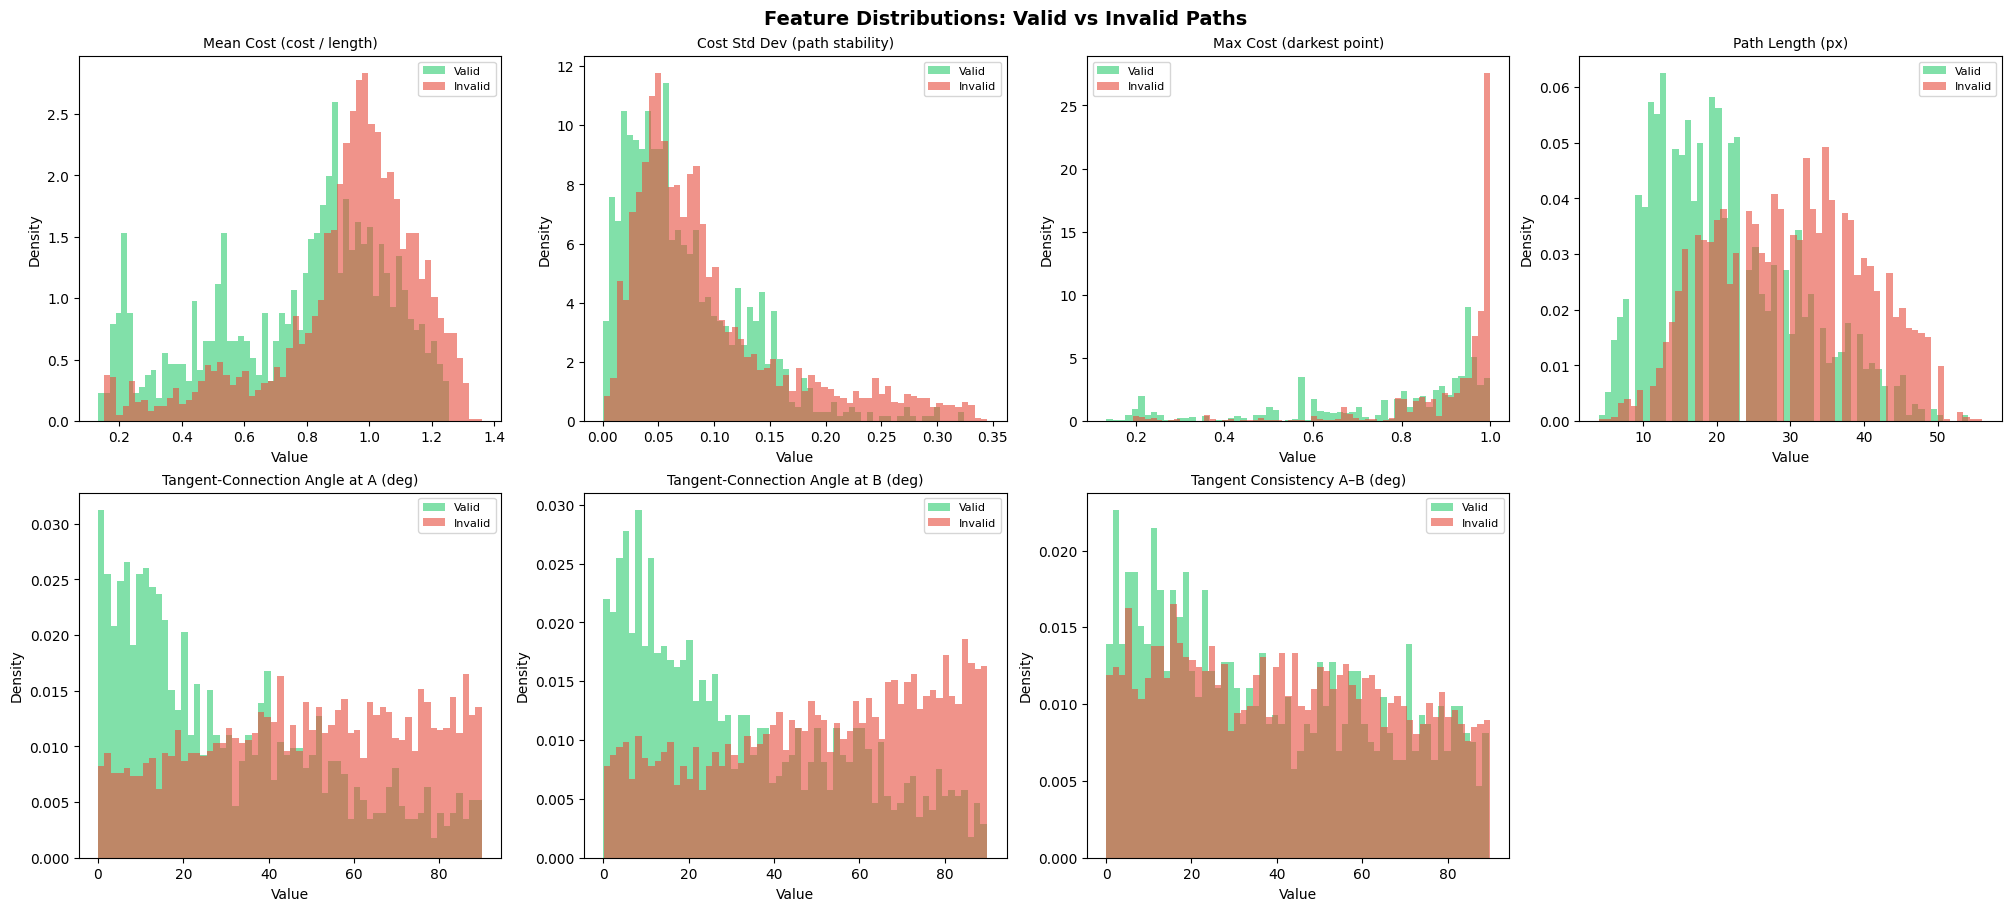

In [23]:

# ============================================================
# Feature distribution: valid vs invalid paths
# ============================================================
feature_meta = [
    ('mean_cost',   'Mean Cost (cost / length)'),
    ('cost_std',    'Cost Std Dev (path stability)'),
    ('max_cost',    'Max Cost (darkest point)'),
    ('path_length', 'Path Length (px)'),
    ('angle_A',     'Tangent-Connection Angle at A (deg)'),
    ('angle_B',     'Tangent-Connection Angle at B (deg)'),
    ('angle_AB',    'Tangent Consistency A–B (deg)'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9), constrained_layout=True)
axes = axes.flatten()

for ax, (feat, title) in zip(axes, feature_meta):
    valid_vals   = df.loc[df['label'] == 'valid',   feat]
    invalid_vals = df.loc[df['label'] == 'invalid', feat]

    bins = 60
    ax.hist(valid_vals,   bins=bins, alpha=0.6, color='#2ecc71', label='Valid',   density=True)
    ax.hist(invalid_vals, bins=bins, alpha=0.6, color='#e74c3c', label='Invalid', density=True)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Feature Distributions: Valid vs Invalid Paths', fontsize=14, fontweight='bold')
plt.show()


Fold 1  AUC = 0.8880
Fold 2  AUC = 0.8884
Fold 3  AUC = 0.8839
Fold 4  AUC = 0.8854

Mean AUC = 0.8864  ±  0.0019


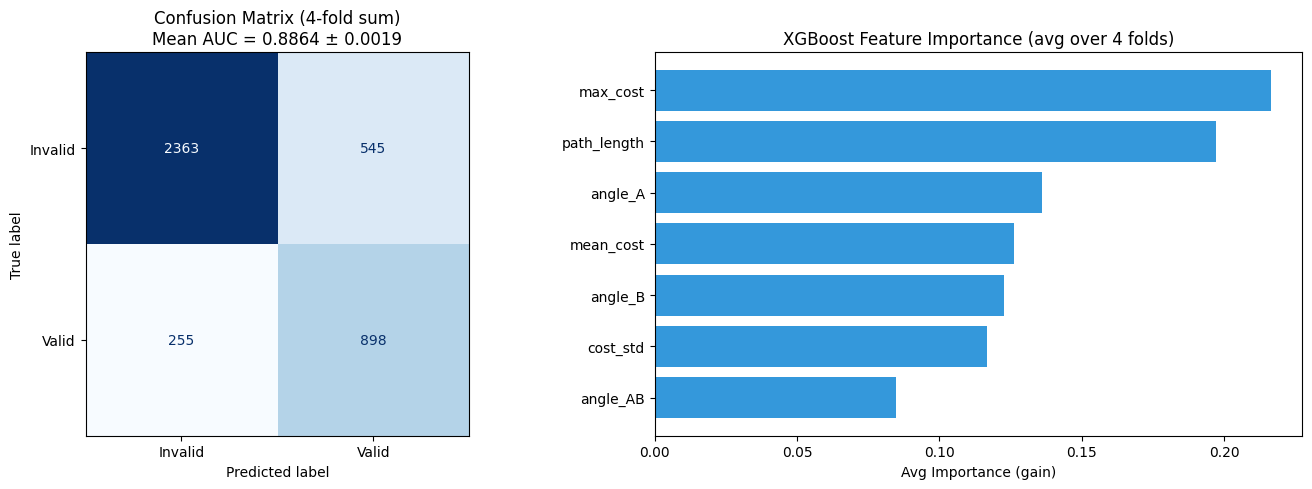

In [24]:

# ============================================================
# XGBoost classifier: 4-fold cross-validation
# ============================================================
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
import numpy as np

FEATURES = ['mean_cost', 'cost_std', 'max_cost', 'path_length',
            'angle_A', 'angle_B', 'angle_AB']

X = df[FEATURES].values
y = (df['label'] == 'valid').astype(int).values   # 1 = valid, 0 = invalid

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

fold_auc    = []
fold_cm     = np.zeros((2, 2), dtype=int)
fold_importance = np.zeros(len(FEATURES))
all_reports = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    clf = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / max(y_train.sum(), 1),
        eval_metric='logloss',
        random_state=42,
    )
    clf.fit(X_train, y_train, verbose=False)

    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    fold_auc.append(auc)
    fold_cm += confusion_matrix(y_test, y_pred)
    fold_importance += clf.feature_importances_
    all_reports.append(classification_report(y_test, y_pred,
                                             target_names=['invalid', 'valid'],
                                             output_dict=True))
    print(f"Fold {fold+1}  AUC = {auc:.4f}")

mean_auc = np.mean(fold_auc)
std_auc  = np.std(fold_auc)
print(f"\nMean AUC = {mean_auc:.4f}  ±  {std_auc:.4f}")

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Aggregated confusion matrix across all folds
disp = ConfusionMatrixDisplay(fold_cm, display_labels=['Invalid', 'Valid'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (4-fold sum)\nMean AUC = {mean_auc:.4f} ± {std_auc:.4f}')

# Average feature importance
avg_importance = fold_importance / 4
order = np.argsort(avg_importance)
axes[1].barh([FEATURES[i] for i in order], avg_importance[order], color='#3498db')
axes[1].set_xlabel('Avg Importance (gain)')
axes[1].set_title('XGBoost Feature Importance (avg over 4 folds)')

plt.tight_layout()
plt.show()


In [25]:
# # Visualize valid and invalid paths drawn on the image
# fig, axes = plt.subplots(2, 1, figsize=(128, 64), constrained_layout=True)

# for ax, path_list, color, title in [
#     (axes[0], valid_path,   (0, 255, 0),   f'Valid Paths (n={len(valid_path)})'),
#     (axes[1], invalid_path, (255, 80, 80),  f'Invalid Paths (n={len(invalid_path)})'),
# ]:
#     viz = cv2.cvtColor(roi_image, cv2.COLOR_GRAY2RGB)
#     viz[roi_label > 0] = [0,0,255]
#     for source, target, path, cost in path_list:
#         for i in range(len(path) - 1):
#             y0, x0 = path[i]
#             y1, x1 = path[i + 1]
#             cv2.line(viz, (x0, y0), (x1, y1), color, 1)
#     ax.imshow(viz)
#     ax.set_title(title, fontsize=12)
#     ax.axis('off')

# plt.suptitle('Valid vs Invalid Path Visualization on Image', fontsize=14)
# plt.show()